In [3]:
!pip install transformers datasets evaluate scikit-learn torch pandas numpy matplotlib

In [4]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("synthetic_trustpilot_tagged_reviews.csv")

# Keep required columns
df = df[["review_title", "review_text", "star_rating", "tag"]].copy()

# Combine title and text into one model input field
df["text"] = (
    df["review_title"].fillna("").astype(str).str.strip() + ". " +
    df["review_text"].fillna("").astype(str).str.strip()
).str.strip()

# Remove rows with no usable text
df = df[df["text"].str.strip() != ""].copy()

print(df.head())
print(df.shape)
print(df["star_rating"].value_counts().sort_index())
print(df["tag"].value_counts())

                   review_title  \
0   Transfer completed smoothly   
1  Login issue resolved quickly   
2       Useful pension forecast   
3       Good digital experience   
4    Slow response from support   

                                         review_text  star_rating  \
0  My pension transfer was handled smoothly from ...            5   
1  Support helped me regain access to the account...            5   
2  The retirement estimate information was presen...            5   
3  The online experience was smooth and straightf...            5   
4  I found the service frustrating and harder tha...            2   

                     tag                                               text  
0       pension_transfer  Transfer completed smoothly. My pension transf...  
1           login_access  Login issue resolved quickly. Support helped m...  
2  retirement_projection  Useful pension forecast. The retirement estima...  
3            website_app  Good digital experience. The online 

In [5]:
def star_to_sentiment(star):
    if star in [1, 2]:
        return "negative"
    elif star == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment_label"] = df["star_rating"].apply(star_to_sentiment)

print(df["sentiment_label"].value_counts())

sentiment_label
positive    11958
negative     2383
neutral       483
Name: count, dtype: int64


In [6]:
# Sentiment encoding
sentiment_labels = sorted(df["sentiment_label"].unique())
sentiment2id = {label: i for i, label in enumerate(sentiment_labels)}
id2sentiment = {i: label for label, i in sentiment2id.items()}
df["sentiment_id"] = df["sentiment_label"].map(sentiment2id)

# Tag encoding
tag_labels = sorted(df["tag"].unique())
tag2id = {label: i for i, label in enumerate(tag_labels)}
id2tag = {i: label for label, i in tag2id.items()}
df["tag_id"] = df["tag"].map(tag2id)

print(sentiment2id)
print(tag2id)

{'negative': 0, 'neutral': 1, 'positive': 2}
{'contributions': 0, 'customer_service': 1, 'fees_charges': 2, 'fund_performance': 3, 'identity_verification': 4, 'login_access': 5, 'pension_transfer': 6, 'retirement_projection': 7, 'website_app': 8, 'withdrawals_retirement': 9}


In [7]:
from sklearn.model_selection import train_test_split

# Sentiment split
train_sent_df, test_sent_df = train_test_split(
    df[["text", "sentiment_id"]],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment_id"]
)

# Tag split
train_tag_df, test_tag_df = train_test_split(
    df[["text", "tag_id"]],
    test_size=0.2,
    random_state=42,
    stratify=df["tag_id"]
)

print(train_sent_df.shape, test_sent_df.shape)
print(train_tag_df.shape, test_tag_df.shape)

(11859, 2) (2965, 2)
(11859, 2) (2965, 2)


Baseline Sentiment Model

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

X_train_sent = train_sent_df["text"]
X_test_sent = test_sent_df["text"]
y_train_sent = train_sent_df["sentiment_id"]
y_test_sent = test_sent_df["sentiment_id"]

baseline_sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=2000))
])

baseline_sentiment_model.fit(X_train_sent, y_train_sent)
baseline_sent_preds = baseline_sentiment_model.predict(X_test_sent)

print("Baseline Sentiment Accuracy:", accuracy_score(y_test_sent, baseline_sent_preds))
print("Baseline Sentiment Weighted F1:", f1_score(y_test_sent, baseline_sent_preds, average="weighted"))
print("Baseline Sentiment Macro F1:", f1_score(y_test_sent, baseline_sent_preds, average="macro"))
print(classification_report(
    y_test_sent,
    baseline_sent_preds,
    target_names=[id2sentiment[i] for i in range(len(id2sentiment))]
))

Baseline Sentiment Accuracy: 0.9554806070826307
Baseline Sentiment Weighted F1: 0.9426234094893943
Baseline Sentiment Macro F1: 0.6731076018165271
              precision    recall  f1-score   support

    negative       0.97      0.93      0.95       477
     neutral       0.50      0.05      0.09        96
    positive       0.95      1.00      0.98      2392

    accuracy                           0.96      2965
   macro avg       0.81      0.66      0.67      2965
weighted avg       0.94      0.96      0.94      2965



Baseline Tag Model

In [9]:
X_train_tag = train_tag_df["text"]
X_test_tag = test_tag_df["text"]
y_train_tag = train_tag_df["tag_id"]
y_test_tag = test_tag_df["tag_id"]

baseline_tag_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000))
])

baseline_tag_model.fit(X_train_tag, y_train_tag)
baseline_tag_preds = baseline_tag_model.predict(X_test_tag)

print("Baseline Tag Accuracy:", accuracy_score(y_test_tag, baseline_tag_preds))
print("Baseline Tag Weighted F1:", f1_score(y_test_tag, baseline_tag_preds, average="weighted"))
print("Baseline Tag Macro F1:", f1_score(y_test_tag, baseline_tag_preds, average="macro"))
print(classification_report(
    y_test_tag,
    baseline_tag_preds,
    target_names=[id2tag[i] for i in range(len(id2tag))]
))

Baseline Tag Accuracy: 0.9993254637436763
Baseline Tag Weighted F1: 0.9993257739988606
Baseline Tag Macro F1: 0.9993753559874691
                        precision    recall  f1-score   support

         contributions       1.00      1.00      1.00       293
      customer_service       1.00      1.00      1.00       424
          fees_charges       1.00      1.00      1.00       207
      fund_performance       1.00      1.00      1.00       354
 identity_verification       1.00      1.00      1.00       208
          login_access       0.99      1.00      1.00       370
      pension_transfer       1.00      1.00      1.00       331
 retirement_projection       1.00      1.00      1.00       272
           website_app       1.00      1.00      1.00       278
withdrawals_retirement       1.00      1.00      1.00       228

              accuracy                           1.00      2965
             macro avg       1.00      1.00      1.00      2965
          weighted avg       1.00    

DistilBERT Sentiment Model

In [10]:
from datasets import Dataset
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_sent_ds = Dataset.from_pandas(train_sent_df.reset_index(drop=True))
test_sent_ds = Dataset.from_pandas(test_sent_df.reset_index(drop=True))

train_sent_ds = train_sent_ds.map(tokenize_function, batched=True)
test_sent_ds = test_sent_ds.map(tokenize_function, batched=True)

train_sent_ds = train_sent_ds.rename_column("sentiment_id", "labels")
test_sent_ds = test_sent_ds.rename_column("sentiment_id", "labels")

train_sent_ds = train_sent_ds.remove_columns(["text"])
test_sent_ds = test_sent_ds.remove_columns(["text"])

train_sent_ds.set_format("torch")
test_sent_ds.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/11859 [00:00<?, ? examples/s]

Map:   0%|          | 0/2965 [00:00<?, ? examples/s]

In [11]:
import evaluate
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1_weighted = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {
        "accuracy": acc["accuracy"],
        "f1_weighted": f1_weighted["f1"],
        "f1_macro": f1_macro["f1"]
    }

sentiment_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(sentiment_labels)
)

sentiment_training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    report_to="none"
)

sentiment_trainer = Trainer(
    model=sentiment_model,
    args=sentiment_training_args,
    train_dataset=train_sent_ds,
    eval_dataset=test_sent_ds,
    compute_metrics=compute_metrics
)

sentiment_trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.160278,0.131472,0.955481,0.939610,0.641678
2,0.132521,0.130374,0.955481,0.939610,0.641678


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1484, training_loss=0.14639983986908534, metrics={'train_runtime': 607.2004, 'train_samples_per_second': 39.061, 'train_steps_per_second': 2.444, 'total_flos': 1570958895983616.0, 'train_loss': 0.14639983986908534, 'epoch': 2.0})

In [12]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

sentiment_pred_output = sentiment_trainer.predict(test_sent_ds)
sentiment_preds = np.argmax(sentiment_pred_output.predictions, axis=1)
sentiment_true = sentiment_pred_output.label_ids

print("DistilBERT Sentiment Accuracy:", accuracy_score(sentiment_true, sentiment_preds))
print("DistilBERT Sentiment Weighted F1:", f1_score(sentiment_true, sentiment_preds, average="weighted"))
print("DistilBERT Sentiment Macro F1:", f1_score(sentiment_true, sentiment_preds, average="macro"))
print(classification_report(
    sentiment_true,
    sentiment_preds,
    target_names=[id2sentiment[i] for i in range(len(id2sentiment))]
))

DistilBERT Sentiment Accuracy: 0.9554806070826307
DistilBERT Sentiment Weighted F1: 0.9396096619515936
DistilBERT Sentiment Macro F1: 0.641677900724765
              precision    recall  f1-score   support

    negative       0.97      0.93      0.95       477
     neutral       0.00      0.00      0.00        96
    positive       0.95      1.00      0.98      2392

    accuracy                           0.96      2965
   macro avg       0.64      0.64      0.64      2965
weighted avg       0.92      0.96      0.94      2965



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


DistilBERT Tag Model

In [13]:
train_tag_ds = Dataset.from_pandas(train_tag_df.reset_index(drop=True))
test_tag_ds = Dataset.from_pandas(test_tag_df.reset_index(drop=True))

train_tag_ds = train_tag_ds.map(tokenize_function, batched=True)
test_tag_ds = test_tag_ds.map(tokenize_function, batched=True)

train_tag_ds = train_tag_ds.rename_column("tag_id", "labels")
test_tag_ds = test_tag_ds.rename_column("tag_id", "labels")

train_tag_ds = train_tag_ds.remove_columns(["text"])
test_tag_ds = test_tag_ds.remove_columns(["text"])

train_tag_ds.set_format("torch")
test_tag_ds.set_format("torch")

Map:   0%|          | 0/11859 [00:00<?, ? examples/s]

Map:   0%|          | 0/2965 [00:00<?, ? examples/s]

In [14]:
tag_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(tag_labels)
)

tag_training_args = TrainingArguments(
    output_dir="./distilbert_tag_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    report_to="none"
)

tag_trainer = Trainer(
    model=tag_model,
    args=tag_training_args,
    train_dataset=train_tag_ds,
    eval_dataset=test_tag_ds,
    compute_metrics=compute_metrics
)

tag_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.183851,0.014066,0.997639,0.997641,0.997473
2,0.003940,0.015286,0.997976,0.997978,0.997898
3,0.001961,0.013644,0.997976,0.997978,0.997898


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2226, training_loss=0.06325070748753303, metrics={'train_runtime': 1008.5876, 'train_samples_per_second': 35.274, 'train_steps_per_second': 2.207, 'total_flos': 2356732504857600.0, 'train_loss': 0.06325070748753303, 'epoch': 3.0})

In [15]:
tag_pred_output = tag_trainer.predict(test_tag_ds)
tag_preds = np.argmax(tag_pred_output.predictions, axis=1)
tag_true = tag_pred_output.label_ids

print("DistilBERT Tag Accuracy:", accuracy_score(tag_true, tag_preds))
print("DistilBERT Tag Weighted F1:", f1_score(tag_true, tag_preds, average="weighted"))
print("DistilBERT Tag Macro F1:", f1_score(tag_true, tag_preds, average="macro"))
print(classification_report(
    tag_true,
    tag_preds,
    target_names=[id2tag[i] for i in range(len(id2tag))]
))

DistilBERT Tag Accuracy: 0.9979763912310287
DistilBERT Tag Weighted F1: 0.9979784664945222
DistilBERT Tag Macro F1: 0.9978978880345155
                        precision    recall  f1-score   support

         contributions       1.00      1.00      1.00       293
      customer_service       1.00      1.00      1.00       424
          fees_charges       1.00      1.00      1.00       207
      fund_performance       1.00      1.00      1.00       354
 identity_verification       1.00      1.00      1.00       208
          login_access       0.99      1.00      1.00       370
      pension_transfer       1.00      0.99      0.99       331
 retirement_projection       1.00      1.00      1.00       272
           website_app       1.00      1.00      1.00       278
withdrawals_retirement       0.98      1.00      0.99       228

              accuracy                           1.00      2965
             macro avg       1.00      1.00      1.00      2965
          weighted avg       1.

Compare baseline vs DistilBERT

In [16]:
results_df = pd.DataFrame([
    {
        "task": "sentiment",
        "model": "TF-IDF + Logistic Regression",
        "accuracy": accuracy_score(y_test_sent, baseline_sent_preds),
        "weighted_f1": f1_score(y_test_sent, baseline_sent_preds, average="weighted"),
        "macro_f1": f1_score(y_test_sent, baseline_sent_preds, average="macro")
    },
    {
        "task": "sentiment",
        "model": "DistilBERT",
        "accuracy": accuracy_score(sentiment_true, sentiment_preds),
        "weighted_f1": f1_score(sentiment_true, sentiment_preds, average="weighted"),
        "macro_f1": f1_score(sentiment_true, sentiment_preds, average="macro")
    },
    {
        "task": "tag",
        "model": "TF-IDF + Logistic Regression",
        "accuracy": accuracy_score(y_test_tag, baseline_tag_preds),
        "weighted_f1": f1_score(y_test_tag, baseline_tag_preds, average="weighted"),
        "macro_f1": f1_score(y_test_tag, baseline_tag_preds, average="macro")
    },
    {
        "task": "tag",
        "model": "DistilBERT",
        "accuracy": accuracy_score(tag_true, tag_preds),
        "weighted_f1": f1_score(tag_true, tag_preds, average="weighted"),
        "macro_f1": f1_score(tag_true, tag_preds, average="macro")
    }
])

print(results_df)

        task                         model  accuracy  weighted_f1  macro_f1
0  sentiment  TF-IDF + Logistic Regression  0.955481     0.942623  0.673108
1  sentiment                    DistilBERT  0.955481     0.939610  0.641678
2        tag  TF-IDF + Logistic Regression  0.999325     0.999326  0.999375
3        tag                    DistilBERT  0.997976     0.997978  0.997898


Hypothesis test for sentiment vs star rating

In [17]:
from scipy.stats import spearmanr
import torch
import numpy as np
import gc

# Optional cleanup
gc.collect()
torch.cuda.empty_cache()

full_df = df.copy()
sentiment_model = sentiment_trainer.model
sentiment_model.eval()

device = next(sentiment_model.parameters()).device
texts = full_df["text"].tolist()

all_preds = []
batch_size = 16   # reduce to 8 if you still get OOM

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i + batch_size]

    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = sentiment_model(**encodings)
        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

    all_preds.extend(batch_preds)

    # cleanup each batch
    del encodings, outputs
    torch.cuda.empty_cache()

full_df["predicted_sentiment_id"] = all_preds

# Make sentiment ordinal for Spearman
ordered_map = {
    "negative": 1,
    "neutral": 2,
    "positive": 3
}

full_df["predicted_sentiment_label"] = [id2sentiment[i] for i in full_df["predicted_sentiment_id"]]
full_df["predicted_sentiment_ordinal"] = full_df["predicted_sentiment_label"].map(ordered_map)

corr, p_value = spearmanr(full_df["predicted_sentiment_ordinal"], full_df["star_rating"])

print("Spearman correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0: there is a statistically significant relationship.")
else:
    print("Fail to reject H0: no statistically significant relationship found.")

Spearman correlation: 0.7961169912362338
p-value: 0.0
Reject H0: there is a statistically significant relationship.


In [18]:
import torch
import numpy as np

def predict_review(review_title, review_text):
    combined_text = f"{review_title}. {review_text}"

    # Use the sentiment model's device
    device = next(sentiment_trainer.model.parameters()).device

    inputs = tokenizer(
        combined_text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    # Move tensors to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    sentiment_trainer.model.eval()
    tag_trainer.model.eval()

    with torch.no_grad():
        sentiment_outputs = sentiment_trainer.model(**inputs)
        tag_outputs = tag_trainer.model(**inputs)

        sentiment_probs = torch.softmax(sentiment_outputs.logits, dim=1).cpu().numpy()[0]
        tag_probs = torch.softmax(tag_outputs.logits, dim=1).cpu().numpy()[0]

    sentiment_pred_id = int(np.argmax(sentiment_probs))
    tag_pred_id = int(np.argmax(tag_probs))

    return {
        "review_title": review_title,
        "review_text": review_text,
        "predicted_sentiment": id2sentiment[sentiment_pred_id],
        "sentiment_confidence": float(sentiment_probs[sentiment_pred_id]),
        "predicted_tag": id2tag[tag_pred_id],
        "tag_confidence": float(tag_probs[tag_pred_id])
    }

example_prediction = predict_review(
    "Trouble logging in",
    "I have tried resetting my password several times and still cannot access my pension account."
)

print(example_prediction)

{'review_title': 'Trouble logging in', 'review_text': 'I have tried resetting my password several times and still cannot access my pension account.', 'predicted_sentiment': 'negative', 'sentiment_confidence': 0.9718070030212402, 'predicted_tag': 'login_access', 'tag_confidence': 0.9990723133087158}


Confusion Matrices

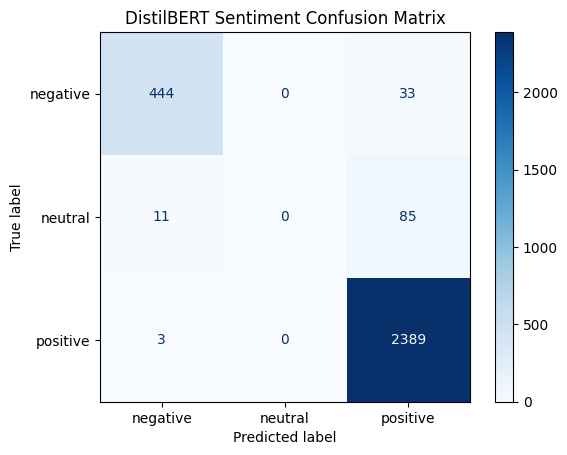

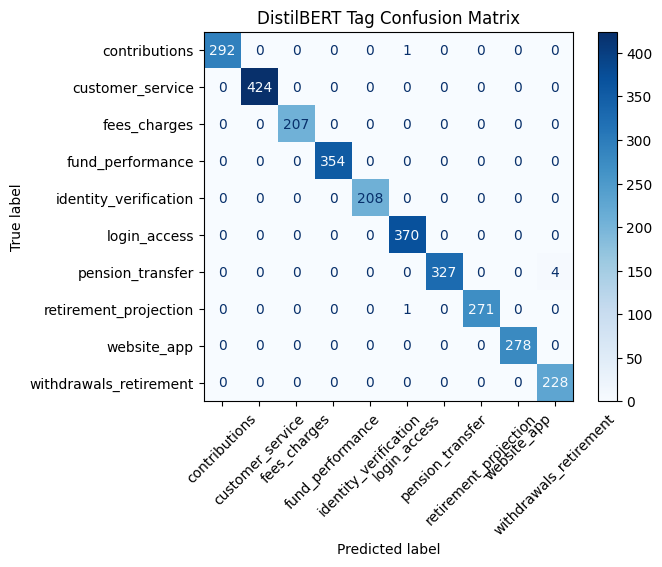

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Sentiment confusion matrix
cm_sent = confusion_matrix(sentiment_true, sentiment_preds)
disp_sent = ConfusionMatrixDisplay(
    confusion_matrix=cm_sent,
    display_labels=[id2sentiment[i] for i in range(len(id2sentiment))]
)
disp_sent.plot(cmap="Blues")
plt.title("DistilBERT Sentiment Confusion Matrix")
plt.show()

# Tag confusion matrix
cm_tag = confusion_matrix(tag_true, tag_preds)
disp_tag = ConfusionMatrixDisplay(
    confusion_matrix=cm_tag,
    display_labels=[id2tag[i] for i in range(len(id2tag))]
)
disp_tag.plot(cmap="Blues", xticks_rotation=45)
plt.title("DistilBERT Tag Confusion Matrix")
plt.show()

In [20]:
import json
import os

os.makedirs("saved_models/sentiment", exist_ok=True)
os.makedirs("saved_models/tag", exist_ok=True)

# Save models + tokenizer
sentiment_trainer.model.save_pretrained("saved_models/sentiment")
tag_trainer.model.save_pretrained("saved_models/tag")
tokenizer.save_pretrained("saved_models/sentiment")
tokenizer.save_pretrained("saved_models/tag")

# Save label maps
with open("saved_models/sentiment/id2label.json", "w") as f:
    json.dump(id2sentiment, f)

with open("saved_models/tag/id2label.json", "w") as f:
    json.dump(id2tag, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Streamlit with ngrok**

In [21]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.9 MB/s eta 0:00:00


In [22]:
%%writefile app.py
import json
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

MAX_LENGTH = 256
BATCH_SIZE = 16


class ReviewClassifier:
    def __init__(
        self,
        sentiment_model_dir: str = "saved_models/sentiment",
        tag_model_dir: str = "saved_models/tag",
    ) -> None:
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.sentiment_tokenizer = DistilBertTokenizerFast.from_pretrained(sentiment_model_dir)
        self.tag_tokenizer = DistilBertTokenizerFast.from_pretrained(tag_model_dir)

        self.sentiment_model = DistilBertForSequenceClassification.from_pretrained(
            sentiment_model_dir
        ).to(self.device)
        self.tag_model = DistilBertForSequenceClassification.from_pretrained(
            tag_model_dir
        ).to(self.device)

        self.sentiment_model.eval()
        self.tag_model.eval()

        with open(Path(sentiment_model_dir) / "id2label.json", "r") as f:
            self.id2sentiment = {int(k): v for k, v in json.load(f).items()}

        with open(Path(tag_model_dir) / "id2label.json", "r") as f:
            self.id2tag = {int(k): v for k, v in json.load(f).items()}

    @staticmethod
    def _combine_text(title: pd.Series, text: pd.Series) -> pd.Series:
        combined = (
            title.fillna("").astype(str).str.strip()
            + ". "
            + text.fillna("").astype(str).str.strip()
        ).str.strip()
        combined = combined.str.replace(r"^\.\s*", "", regex=True)
        return combined

    def _predict_batch(self, texts: list[str]):
        sentiment_labels, sentiment_scores = [], []
        tag_labels, tag_scores = [], []

        for i in range(0, len(texts), BATCH_SIZE):
            batch_texts = texts[i:i + BATCH_SIZE]

            sentiment_inputs = self.sentiment_tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            sentiment_inputs = {k: v.to(self.device) for k, v in sentiment_inputs.items()}

            tag_inputs = self.tag_tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            tag_inputs = {k: v.to(self.device) for k, v in tag_inputs.items()}

            with torch.no_grad():
                sentiment_outputs = self.sentiment_model(**sentiment_inputs)
                tag_outputs = self.tag_model(**tag_inputs)

                sentiment_probs = torch.softmax(sentiment_outputs.logits, dim=1).cpu().numpy()
                tag_probs = torch.softmax(tag_outputs.logits, dim=1).cpu().numpy()

            sentiment_ids = np.argmax(sentiment_probs, axis=1)
            tag_ids = np.argmax(tag_probs, axis=1)

            sentiment_labels.extend([self.id2sentiment[int(idx)] for idx in sentiment_ids])
            sentiment_scores.extend(
                [float(sentiment_probs[j, idx]) for j, idx in enumerate(sentiment_ids)]
            )

            tag_labels.extend([self.id2tag[int(idx)] for idx in tag_ids])
            tag_scores.extend([float(tag_probs[j, idx]) for j, idx in enumerate(tag_ids)])

        return sentiment_labels, sentiment_scores, tag_labels, tag_scores

    def predict_dataframe(
        self,
        df: pd.DataFrame,
        title_col: str = "review_title",
        text_col: str = "review_text",
    ) -> pd.DataFrame:
        if title_col not in df.columns or text_col not in df.columns:
            raise ValueError(
                f"Input CSV must contain '{title_col}' and '{text_col}' columns."
            )

        output_df = df.copy()
        output_df["combined_text"] = self._combine_text(output_df[title_col], output_df[text_col])
        output_df = output_df[output_df["combined_text"].str.strip() != ""].copy()

        texts = output_df["combined_text"].tolist()
        sent_labels, sent_scores, tag_labels, tag_scores = self._predict_batch(texts)

        output_df["predicted_sentiment"] = sent_labels
        output_df["sentiment_confidence"] = sent_scores
        output_df["predicted_tag"] = tag_labels
        output_df["tag_confidence"] = tag_scores

        return output_df


st.set_page_config(page_title="Trustpilot Review Classifier", layout="wide")
st.title("Trustpilot Review Classifier")
st.write("Upload a CSV file to generate sentiment and tag predictions.")

@st.cache_resource
def load_classifier():
    return ReviewClassifier()

classifier = load_classifier()

uploaded_file = st.file_uploader("Upload CSV", type=["csv"])
title_col = st.text_input("Title column name", value="review_title")
text_col = st.text_input("Text column name", value="review_text")

if uploaded_file is not None:
    try:
        df = pd.read_csv(uploaded_file)
        st.subheader("Input Preview")
        st.dataframe(df.head(), use_container_width=True)

        if st.button("Run Prediction"):
            with st.spinner("Generating predictions..."):
                result_df = classifier.predict_dataframe(
                    df,
                    title_col=title_col,
                    text_col=text_col,
                )

            st.subheader("Prediction Output")
            st.dataframe(result_df.head(20), use_container_width=True)

            csv_data = result_df.to_csv(index=False).encode("utf-8")
            st.download_button(
                label="Download output CSV",
                data=csv_data,
                file_name="reviews_with_predictions.csv",
                mime="text/csv",
            )

    except Exception as e:
        st.error(f"Error: {e}")

Writing app.py


In [23]:
!streamlit run app.py --server.port 8503 &>/content/logs.txt &

In [24]:
from pyngrok import ngrok

ngrok.set_auth_token("3BPa15tXDmUldP2Bcup2LORnEEp_283nAJy26A1R4Uynipo27")

In [25]:
public_url = ngrok.connect(8503)
print(public_url)

NgrokTunnel: "https://stodgily-subconsular-antoinette.ngrok-free.dev" -> "http://localhost:8503"


Github


In [26]:
!git --version

git version 2.34.1


In [27]:
!git config --global user.name "Harsh46"
!git config --global user.email "harshdeepjoy@gmail.com"

In [30]:
!git clone https://github.com/Harsh46/trustpilot-review-classifier.git

Cloning into 'trustpilot-review-classifier'...


In [31]:
%cd trustpilot-review-classifier

/content/trustpilot-review-classifier


In [32]:
%%writefile requirements.txt
pandas
numpy
torch
transformers
streamlit

Writing requirements.txt


In [33]:
%%writefile README.md
# Trustpilot Review Classifier

NLP-based system using a fine-tuned DistilBERT model to classify customer reviews.

## Run
streamlit run app.py

Writing README.md


In [35]:
!cp AIDI_Assessment.ipynb .

cp: cannot stat 'AIDI_Assessment.ipynb': No such file or directory


In [36]:
!ls

README.md  requirements.txt
